In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("data/sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [11]:
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)

In [13]:
df.columns

Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

In [15]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [17]:
df = pd.get_dummies(df, columns=["Product", "Region"], drop_first=True)

In [19]:
X = df.drop(["Quantity", "Customer_ID", "Date"], axis=1)
y = df["Quantity"]

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.7773767342582711
MAE: 0.8865000000000002


In [25]:
import pickle

model = pickle.load(open("deployment/model.pkl", "rb"))

In [27]:
df.shape


(100, 14)

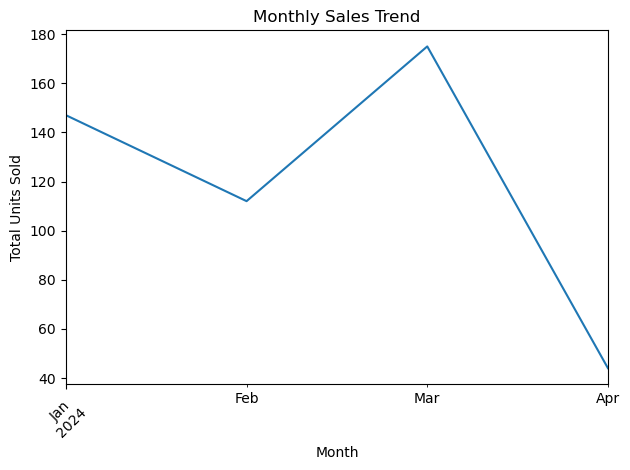

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/sales_data.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract Month
df["Month"] = df["Date"].dt.to_period("M")

# Aggregate monthly quantity
monthly_sales = df.groupby("Month")["Quantity"].sum()

# Plot
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

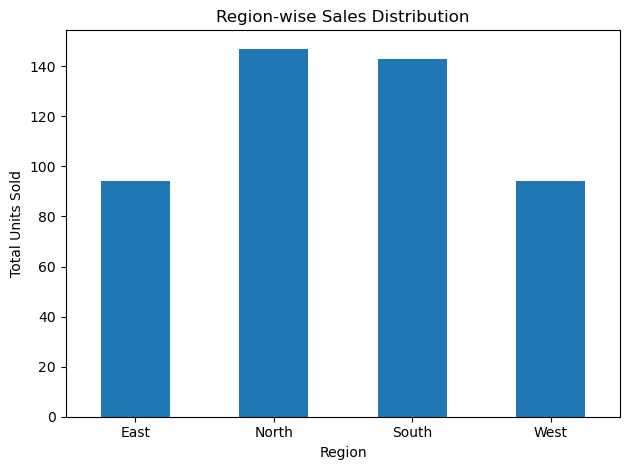

In [31]:
# Aggregate by Region
region_sales = df.groupby("Region")["Quantity"].sum()

# Plot
plt.figure()
region_sales.plot(kind="bar")
plt.title("Region-wise Sales Distribution")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()